# Our Contribution: Dual-Stream Counterfeit Medicine Detection

**Base Paper:** *"Analyzing the Counterfeit Medicines Based on Classification Using Machine Learning Techniques"*  
**Authors:** Binitha S. Thomson and W. Rose Varuna

---

### What the Paper Does
The base paper classifies medicines as authentic/counterfeit using **visual features** (Color, Texture, Shape, Edges) and 4 ML classifiers (RF, NB, KNN, SVM).

### Our 3 Contributions

| # | Contribution | Description |
|---|-------------|-------------|
| 1 | **Dual-Stream Architecture** | We add a second feature stream based on **OCR text analysis** — extracting 8 text-quality features using EasyOCR, then fusing them with the visual features |
| 2 | **XGBoost Classifier** | We add a 5th classifier (XGBoost) beyond the paper's 4 |
| 3 | **SHAP Explainability** | We use SHAP values to explain *why* models make specific predictions — which feature groups matter most |

---
## 1. Setup & Load Data from Paper Implementation

We load the pre-computed visual features, trained models, and image paths  
from the base paper notebook via `pipeline_data.pkl`.

In [1]:
import os, pickle, time, warnings
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, precision_score,
                             recall_score, f1_score)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
os.makedirs('results', exist_ok=True)
print('Libraries imported.')

Libraries imported.


In [2]:
# Load saved pipeline data from paper_implementation.ipynb
data = pickle.load(open('pipeline_data.pkl', 'rb'))

X_train_visual = data['X_train']       # (6657, 2314) visual features
X_test_visual  = data['X_test']        # (1665, 2314)
y_tr           = data['y_tr']          # train labels
y_te           = data['y_te']          # test labels
paths_train    = data['paths_train']   # image paths for train
paths_test     = data['paths_test']    # image paths for test
paper_results  = data['results']       # paper model results
scaler_visual  = data['scaler']        # fitted scaler for visual features

print(f'Visual features loaded:')
print(f'  Train: {X_train_visual.shape} | Test: {X_test_visual.shape}')
print(f'  Labels — Train: {len(y_tr)} (auth={np.sum(y_tr==0)}, fake={np.sum(y_tr==1)})')
print(f'  Labels — Test:  {len(y_te)} (auth={np.sum(y_te==0)}, fake={np.sum(y_te==1)})')
print(f'\nPaper Results (Visual-Only):')
for name, r in paper_results.items():
    print(f'  {name}: {r["accuracy"]:.2f}%')

Visual features loaded:
  Train: (6657, 2314) | Test: (1665, 2314)
  Labels — Train: 6657 (auth=5769, fake=888)
  Labels — Test:  1665 (auth=1443, fake=222)

Paper Results (Visual-Only):
  Random Forest (RF): 92.49%
  Naive Bayes (NB): 81.08%
  KNN: 93.69%
  SVM: 96.82%
  XGBoost: 97.96%


---
## 2. Stream B: OCR Feature Extraction

Counterfeit medicines often have **poor print quality**, missing text, or blurry labels.  
We use **EasyOCR** to detect text regions in each medicine crop and extract 8 features:

| # | Feature | What it captures |
|---|---------|------------------|
| 1 | `n_text_regions` | Number of detected text blocks |
| 2 | `total_chars` | Total character count across all text |
| 3 | `avg_confidence` | Mean OCR confidence — lower on blurry/fake text |
| 4 | `max_confidence` | Best quality text region |
| 5 | `min_confidence` | Worst quality text (most degraded) |
| 6 | `confidence_std` | Inconsistent print quality on counterfeits |
| 7 | `text_area_ratio` | Fraction of image covered by text |
| 8 | `char_density` | Characters per unit text area (font size proxy) |

### 2.1 Initialize OCR Engine

In [3]:
import easyocr

reader = easyocr.Reader(['en'], gpu=False, verbose=False)
print('EasyOCR initialized (English, CPU mode).')

EasyOCR initialized (English, CPU mode).


### 2.2 Define OCR Feature Extraction Function

In [4]:
def extract_ocr_features(img_path, reader):
    """
    Extract 8 OCR-based features from a medicine image.
    Returns zeros if no text is detected or image can't be read.
    """
    img = cv2.imread(img_path)
    if img is None:
        return np.zeros(8)
    
    h, w = img.shape[:2]
    img_area = h * w
    
    try:
        results = reader.readtext(img)
    except:
        return np.zeros(8)
    
    if len(results) == 0:
        return np.zeros(8)
    
    # Parse OCR results
    confidences = []
    total_chars = 0
    total_text_area = 0
    
    for (bbox, text, conf) in results:
        confidences.append(conf)
        total_chars += len(text)
        # bbox is 4 corner points: [[x1,y1],[x2,y2],[x3,y3],[x4,y4]]
        xs = [p[0] for p in bbox]
        ys = [p[1] for p in bbox]
        box_w = max(xs) - min(xs)
        box_h = max(ys) - min(ys)
        total_text_area += box_w * box_h
    
    confidences = np.array(confidences)
    
    features = np.array([
        len(results),                                    # 1. n_text_regions
        total_chars,                                     # 2. total_chars
        np.mean(confidences),                            # 3. avg_confidence
        np.max(confidences),                             # 4. max_confidence
        np.min(confidences),                             # 5. min_confidence
        np.std(confidences) if len(confidences) > 1 else 0,  # 6. confidence_std
        total_text_area / max(img_area, 1),              # 7. text_area_ratio
        total_chars / max(total_text_area, 1),           # 8. char_density
    ])
    
    return features

# Quick test on one image
test_feat = extract_ocr_features(paths_train[0], reader)
feature_names = ['n_text_regions', 'total_chars', 'avg_confidence',
                 'max_confidence', 'min_confidence', 'confidence_std',
                 'text_area_ratio', 'char_density']
print('OCR Feature test:')
for name, val in zip(feature_names, test_feat):
    print(f'  {name}: {val:.4f}')

OCR Feature test:
  n_text_regions: 11.0000
  total_chars: 13.0000
  avg_confidence: 0.3985
  max_confidence: 0.9290
  min_confidence: 0.1306
  confidence_std: 0.2429
  text_area_ratio: 0.2199
  char_density: 0.0002


### 2.3 Extract OCR Features for All Images

This takes approximately **10–15 minutes** as OCR processes each crop individually.

In [5]:
def extract_ocr_batch(paths, reader, name=''):
    """Extract OCR features for a batch of images with progress."""
    feats = []
    total = len(paths)
    t0 = time.time()
    for i, p in enumerate(paths):
        if (i+1) % 200 == 0 or i == total-1:
            elapsed = time.time() - t0
            eta = (elapsed / (i+1)) * (total - i - 1)
            print(f'  {name}: {i+1}/{total} ({elapsed:.0f}s elapsed, ~{eta:.0f}s remaining)', end='\r')
        feats.append(extract_ocr_features(p, reader))
    print()
    return np.array(feats)

print('Extracting OCR features for TRAIN set...')
X_train_ocr = extract_ocr_batch(paths_train, reader, 'Train')

print('Extracting OCR features for TEST set...')
X_test_ocr = extract_ocr_batch(paths_test, reader, 'Test')

print(f'\nOCR Features: train={X_train_ocr.shape}, test={X_test_ocr.shape}')

# Save OCR features so we don't have to re-extract
pickle.dump({'X_train_ocr': X_train_ocr, 'X_test_ocr': X_test_ocr},
            open('ocr_features.pkl', 'wb'))
print('OCR features saved to ocr_features.pkl')

Extracting OCR features for TRAIN set...
  Train: 6657/6657 (4138s elapsed, ~0s remaining))))
Extracting OCR features for TEST set...
  Test: 1665/1665 (1066s elapsed, ~0s remaining))

OCR Features: train=(6657, 8), test=(1665, 8)
OCR features saved to ocr_features.pkl


---
## 3. OCR Feature Visualization

### 3.1 Sample Images with OCR Detections

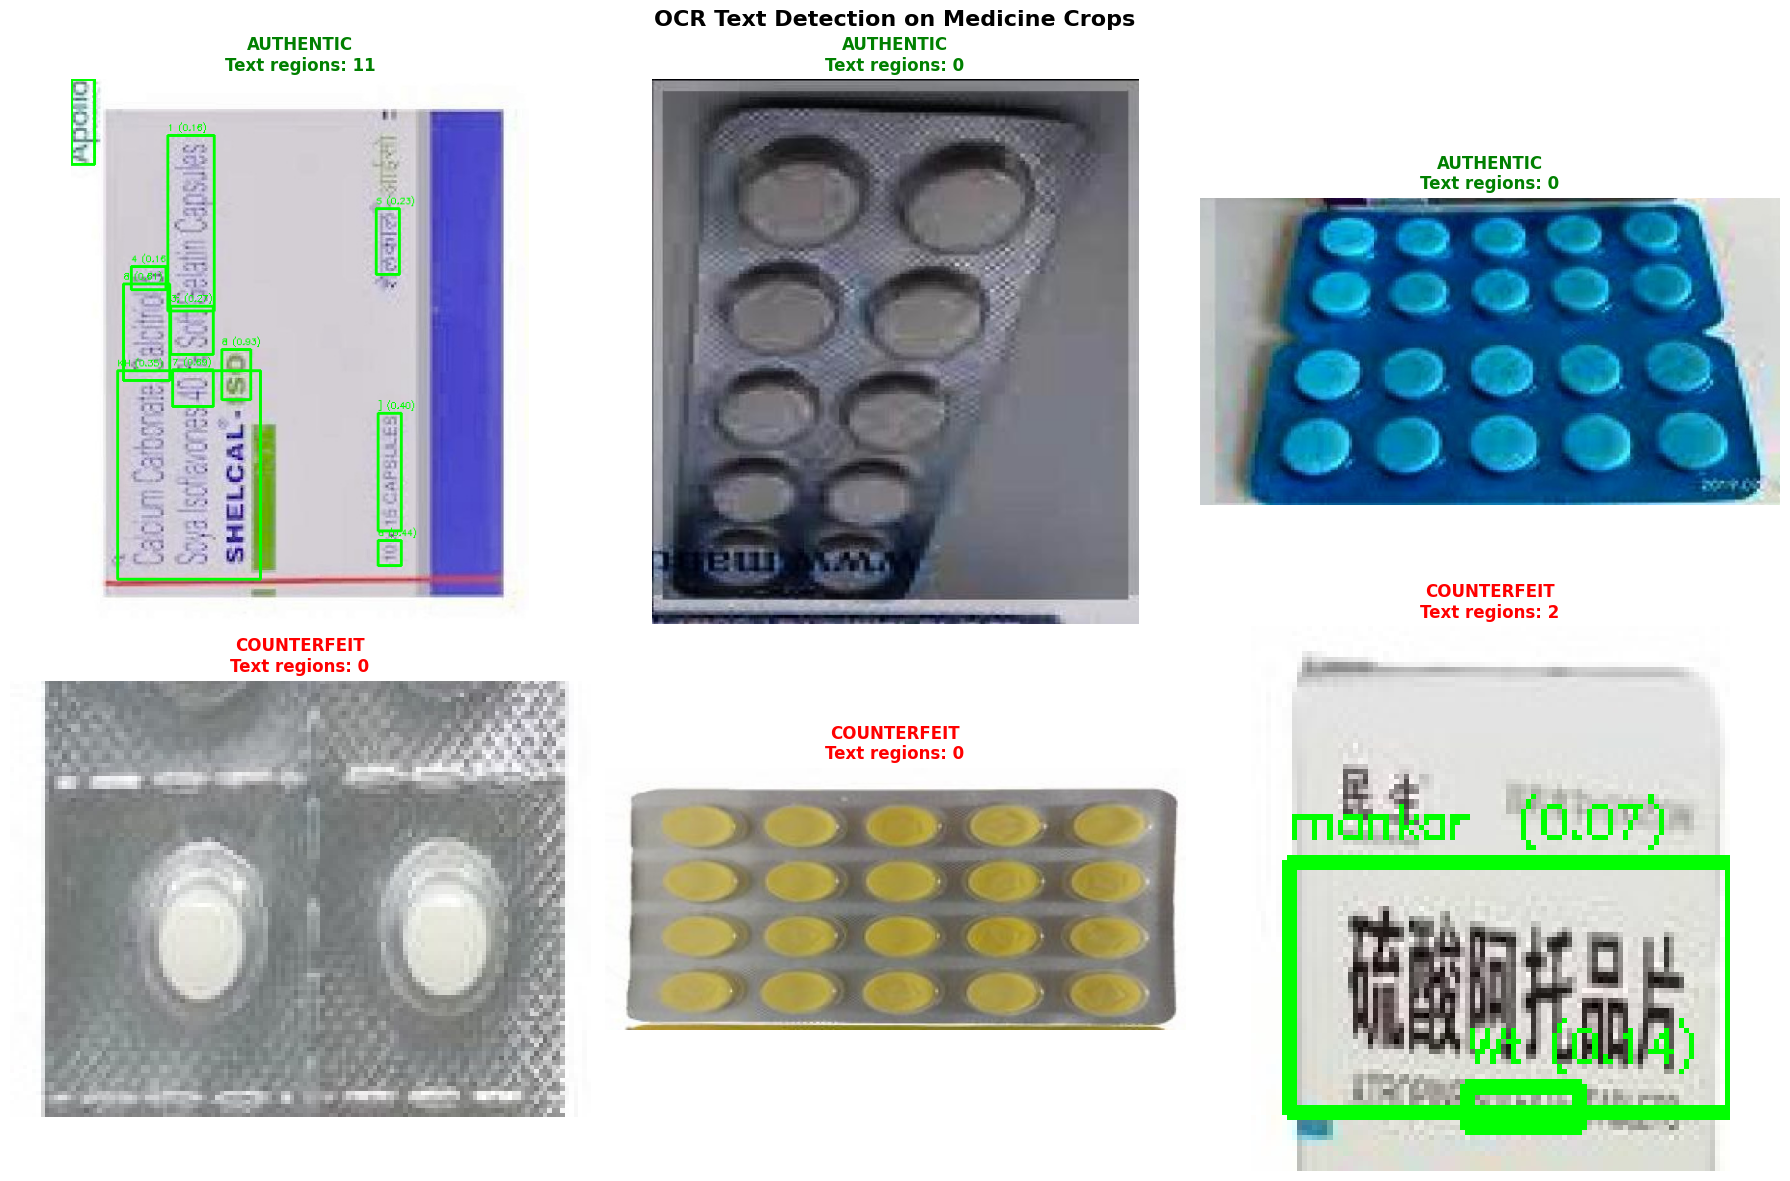

In [6]:
# Show 6 images: 3 authentic, 3 counterfeit with OCR boxes
auth_idx = [i for i, y in enumerate(y_tr) if y == 0][:3]
fake_idx = [i for i, y in enumerate(y_tr) if y == 1][:3]
sample_idx = auth_idx + fake_idx

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for i, idx in enumerate(sample_idx):
    ax = axes[i // 3, i % 3]
    img = cv2.imread(paths_train[idx])
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Run OCR and draw boxes
    ocr_results = reader.readtext(img)
    for (bbox, text, conf) in ocr_results:
        pts = np.array(bbox, dtype=np.int32)
        cv2.polylines(img_rgb, [pts], True, (0, 255, 0), 2)
        cv2.putText(img_rgb, f'{text} ({conf:.2f})', (pts[0][0], pts[0][1]-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0, 255, 0), 1)
    
    label = 'AUTHENTIC' if y_tr[idx] == 0 else 'COUNTERFEIT'
    color = 'green' if y_tr[idx] == 0 else 'red'
    ax.imshow(img_rgb)
    ax.set_title(f'{label}\nText regions: {len(ocr_results)}', color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle('OCR Text Detection on Medicine Crops', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('results/ocr_samples.png', dpi=150)
plt.show()

### 3.2 OCR Feature Statistics by Class

In [7]:
# Mean OCR features per class
ocr_df = pd.DataFrame(X_train_ocr, columns=feature_names)
ocr_df['class'] = ['Authentic' if y == 0 else 'Counterfeit' for y in y_tr]

print('Mean OCR Feature Values by Class:')
print('=' * 60)
mean_table = ocr_df.groupby('class')[feature_names].mean().T
mean_table['Difference'] = mean_table['Counterfeit'] - mean_table['Authentic']
print(mean_table.round(4).to_string())

Mean OCR Feature Values by Class:
class            Authentic  Counterfeit  Difference
n_text_regions      2.3694       1.7320     -0.6374
total_chars        14.1295       9.5766     -4.5529
avg_confidence      0.1424       0.1110     -0.0314
max_confidence      0.2637       0.1778     -0.0859
min_confidence      0.0565       0.0672      0.0106
confidence_std      0.0802       0.0432     -0.0370
text_area_ratio     0.0924       0.0875     -0.0050
char_density        0.0005       0.0019      0.0014


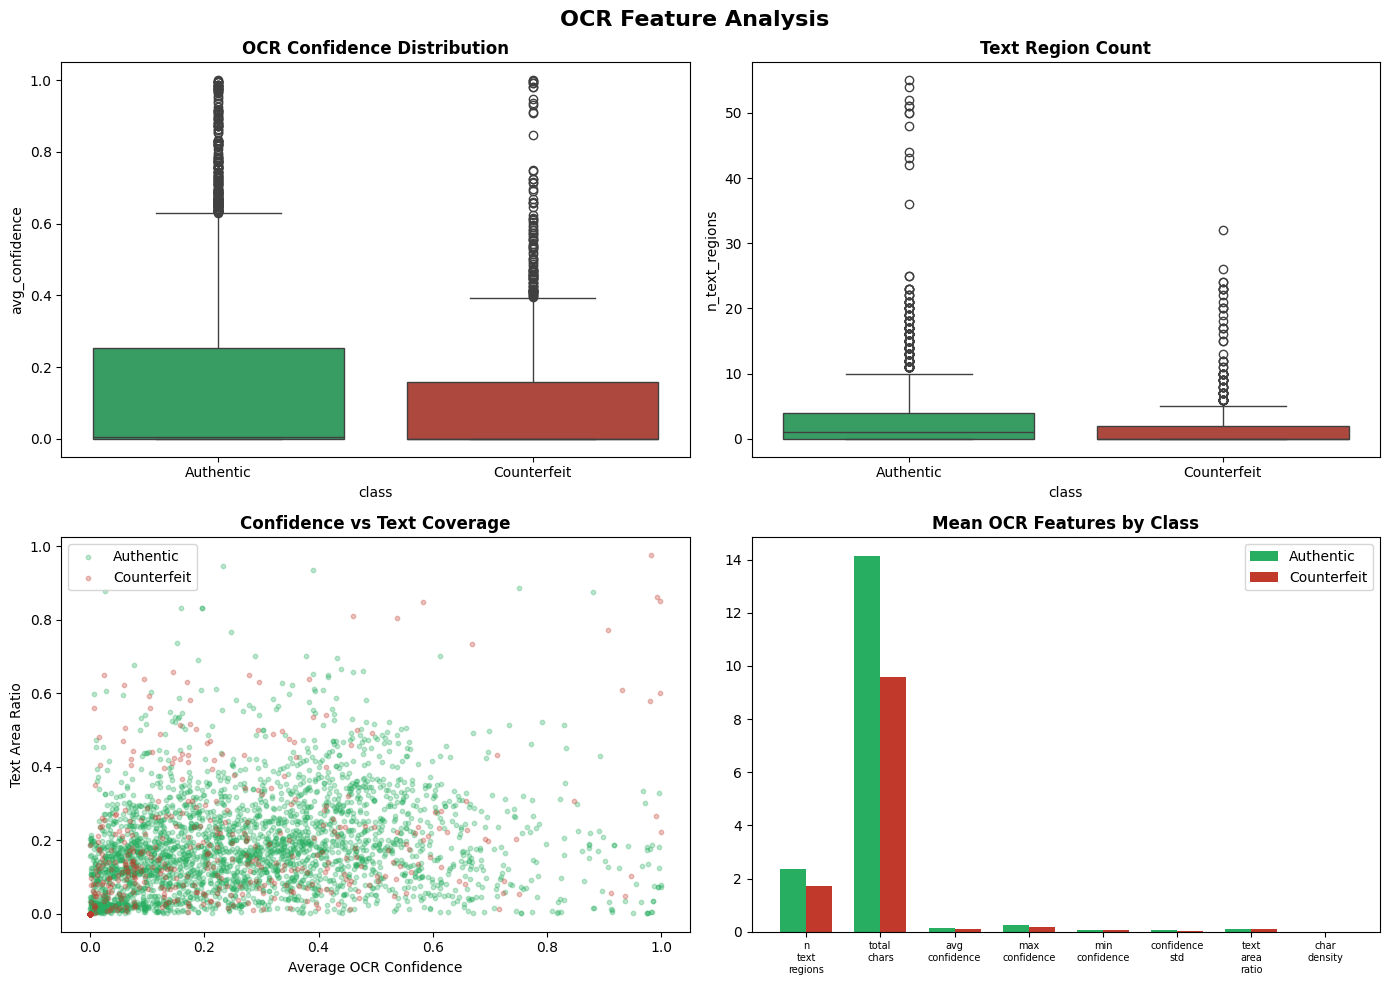

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Box plot: avg_confidence by class
sns.boxplot(data=ocr_df, x='class', y='avg_confidence', ax=axes[0,0],
            palette={'Authentic': '#27ae60', 'Counterfeit': '#c0392b'})
axes[0,0].set_title('OCR Confidence Distribution', fontweight='bold')

# 2. Box plot: n_text_regions by class
sns.boxplot(data=ocr_df, x='class', y='n_text_regions', ax=axes[0,1],
            palette={'Authentic': '#27ae60', 'Counterfeit': '#c0392b'})
axes[0,1].set_title('Text Region Count', fontweight='bold')

# 3. Scatter: avg_confidence vs text_area_ratio
for cls, color in [('Authentic', '#27ae60'), ('Counterfeit', '#c0392b')]:
    mask = ocr_df['class'] == cls
    axes[1,0].scatter(ocr_df[mask]['avg_confidence'], ocr_df[mask]['text_area_ratio'],
                      alpha=0.3, s=10, c=color, label=cls)
axes[1,0].set_xlabel('Average OCR Confidence')
axes[1,0].set_ylabel('Text Area Ratio')
axes[1,0].set_title('Confidence vs Text Coverage', fontweight='bold')
axes[1,0].legend()

# 4. Bar: mean features comparison
mean_auth = X_train_ocr[y_tr == 0].mean(axis=0)
mean_fake = X_train_ocr[y_tr == 1].mean(axis=0)
x = np.arange(len(feature_names))
w = 0.35
axes[1,1].bar(x - w/2, mean_auth, w, label='Authentic', color='#27ae60')
axes[1,1].bar(x + w/2, mean_fake, w, label='Counterfeit', color='#c0392b')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels([n.replace('_', '\n') for n in feature_names], fontsize=7)
axes[1,1].set_title('Mean OCR Features by Class', fontweight='bold')
axes[1,1].legend()

plt.suptitle('OCR Feature Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('results/ocr_class_comparison.png', dpi=150)
plt.show()

---
## 4. Feature Fusion — Three Configurations

We create **3 feature configurations** to measure the impact of each stream:

| Config | Features | Dimensions | Purpose |
|--------|----------|------------|---------|
| **A: Visual Only** | Color + LBP + GLCM + Hu + HOG | 2,314 | Baseline (paper approach) |
| **B: OCR Only** | 8 OCR text features | 8 | Shows OCR discriminative power alone |
| **C: Fused** | Visual + OCR concatenated | 2,322 | Our contribution — dual-stream |

In [9]:
# Config A: Visual Only (already scaled)
X_train_A = data['X_train_sc']  # pre-scaled visual features
X_test_A  = data['X_test_sc']

# Config B: OCR Only (needs scaling)
scaler_ocr = StandardScaler()
X_train_B = scaler_ocr.fit_transform(X_train_ocr)
X_test_B  = scaler_ocr.transform(X_test_ocr)

# Config C: Fused (Visual + OCR, scale together)
X_train_fused_raw = np.hstack([X_train_visual, X_train_ocr])
X_test_fused_raw  = np.hstack([X_test_visual, X_test_ocr])
scaler_fused = StandardScaler()
X_train_C = scaler_fused.fit_transform(X_train_fused_raw)
X_test_C  = scaler_fused.transform(X_test_fused_raw)

configs = {
    'A: Visual Only': (X_train_A, X_test_A),
    'B: OCR Only':    (X_train_B, X_test_B),
    'C: Fused':       (X_train_C, X_test_C),
}

for name, (tr, te) in configs.items():
    print(f'{name}: train={tr.shape}, test={te.shape}')

A: Visual Only: train=(6657, 2314), test=(1665, 2314)
B: OCR Only: train=(6657, 8), test=(1665, 8)
C: Fused: train=(6657, 2322), test=(1665, 2322)


---
## 5. Train All Configurations

**5 classifiers × 3 configs = 15 training runs**

Each model is trained fresh on each config and evaluated on the test set.

In [10]:
def get_classifiers():
    """Return a fresh set of classifiers for each config."""
    scale_pos = np.sum(y_tr == 0) / max(np.sum(y_tr == 1), 1)
    return {
        'RF':  RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
        'NB':  GaussianNB(),
        'KNN': KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1),
        'SVM': SVC(kernel='rbf', class_weight='balanced', C=10, gamma='scale', random_state=42),
        'XGB': XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                             scale_pos_weight=scale_pos, eval_metric='logloss',
                             random_state=42, n_jobs=-1)
    }

In [11]:
all_results = {}  # key: (config_name, model_name) -> dict
trained_fused_models = {}  # store Config C models for SHAP

for config_name, (X_tr, X_te) in configs.items():
    print(f'\n{"="*60}')
    print(f'CONFIG: {config_name} ({X_tr.shape[1]} features)')
    print(f'{"="*60}')
    
    clfs = get_classifiers()
    for model_name, clf in clfs.items():
        print(f'  Training {model_name}...', end=' ')
        t0 = time.time()
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_te)
        elapsed = time.time() - t0
        
        acc = accuracy_score(y_te, y_pred) * 100
        prec = precision_score(y_te, y_pred, average='weighted') * 100
        rec = recall_score(y_te, y_pred, average='weighted') * 100
        f1 = f1_score(y_te, y_pred, average='weighted') * 100
        
        all_results[(config_name, model_name)] = {
            'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1,
            'time': elapsed, 'y_pred': y_pred,
            'cm': confusion_matrix(y_te, y_pred),
            'report': classification_report(y_te, y_pred, target_names=['Authentic','Counterfeit'])
        }
        
        # Save fused models for SHAP
        if config_name == 'C: Fused':
            trained_fused_models[model_name] = clf
        
        print(f'{acc:.2f}% ({elapsed:.1f}s)')

print(f'\nTotal experiments: {len(all_results)}')


CONFIG: A: Visual Only (2314 features)
  Training RF... 91.17% (2.7s)
  Training NB... 81.08% (0.4s)
  Training KNN... 93.69% (3.8s)
  Training SVM... 96.82% (34.8s)
  Training XGB... 97.84% (33.7s)

CONFIG: B: OCR Only (8 features)
  Training RF... 55.20% (0.4s)
  Training NB... 86.67% (0.0s)
  Training KNN... 88.89% (0.1s)
  Training SVM... 56.04% (1.8s)
  Training XGB... 57.24% (0.3s)

CONFIG: C: Fused (2322 features)
  Training RF... 91.41% (2.6s)
  Training NB... 81.38% (0.3s)
  Training KNN... 93.81% (0.4s)
  Training SVM... 96.82% (34.9s)
  Training XGB... 97.84% (32.5s)

Total experiments: 15


---
## 6. Results & Comparison

### 6.1 Complete 15-Experiment Comparison Table

In [12]:
# Build comparison table
rows = []
for (config, model), r in all_results.items():
    rows.append({
        'Config': config, 'Model': model,
        'Accuracy (%)': round(r['accuracy'], 2),
        'Precision (%)': round(r['precision'], 2),
        'Recall (%)': round(r['recall'], 2),
        'F1-Score (%)': round(r['f1'], 2),
        'Time (s)': round(r['time'], 2)
    })

df = pd.DataFrame(rows)
print('\n' + '='*90)
print('COMPLETE 15-EXPERIMENT COMPARISON TABLE')
print('='*90)
print(df.to_string(index=False))
print('='*90)


COMPLETE 15-EXPERIMENT COMPARISON TABLE
        Config Model  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)  Time (s)
A: Visual Only    RF         91.17          91.52       91.17         89.36      2.72
A: Visual Only    NB         81.08          87.89       81.08         83.32      0.38
A: Visual Only   KNN         93.69          93.67       93.69         93.02      3.84
A: Visual Only   SVM         96.82          96.76       96.82         96.71     34.76
A: Visual Only   XGB         97.84          97.82       97.84         97.78     33.69
   B: OCR Only    RF         55.20          84.19       55.20         61.98      0.35
   B: OCR Only    NB         86.67          83.42       86.67         83.90      0.00
   B: OCR Only   KNN         88.89          88.03       88.89         86.02      0.09
   B: OCR Only   SVM         56.04          88.26       56.04         62.40      1.79
   B: OCR Only   XGB         57.24          88.25       57.24         63.55      0.31
      C: Fuse

### 6.2 Visual Only vs OCR Only vs Fused — Summary Table

In [13]:
# Pivot table: rows=models, cols=configs, values=accuracy
pivot = df.pivot_table(index='Model', columns='Config', values='Accuracy (%)',
                       aggfunc='first')
pivot = pivot[['A: Visual Only', 'B: OCR Only', 'C: Fused']]  # order columns
pivot['\u0394 (Fused - Visual)'] = pivot['C: Fused'] - pivot['A: Visual Only']

print('\nAccuracy by Configuration:')
print('='*70)
print(pivot.to_string())
print('='*70)


Accuracy by Configuration:
Config  A: Visual Only  B: OCR Only  C: Fused  Δ (Fused - Visual)
Model                                                            
KNN              93.69        88.89     93.81                0.12
NB               81.08        86.67     81.38                0.30
RF               91.17        55.20     91.41                0.24
SVM              96.82        56.04     96.82                0.00
XGB              97.84        57.24     97.84                0.00


### 6.3 Classification Reports (Fused Config)

In [14]:
for (config, model), r in all_results.items():
    if config == 'C: Fused':
        print(f'=== {model} (Fused)  |  Accuracy: {r["accuracy"]:.2f}% ===')
        print(r['report'])

=== RF (Fused)  |  Accuracy: 91.41% ===
              precision    recall  f1-score   support

   Authentic       0.91      1.00      0.95      1443
 Counterfeit       0.98      0.36      0.53       222

    accuracy                           0.91      1665
   macro avg       0.94      0.68      0.74      1665
weighted avg       0.92      0.91      0.90      1665

=== NB (Fused)  |  Accuracy: 81.38% ===
              precision    recall  f1-score   support

   Authentic       0.96      0.82      0.88      1443
 Counterfeit       0.40      0.75      0.52       222

    accuracy                           0.81      1665
   macro avg       0.68      0.79      0.70      1665
weighted avg       0.88      0.81      0.84      1665

=== KNN (Fused)  |  Accuracy: 93.81% ===
              precision    recall  f1-score   support

   Authentic       0.94      0.99      0.97      1443
 Counterfeit       0.94      0.57      0.71       222

    accuracy                           0.94      1665
   macr

### 6.4 Confusion Matrices (Fused Config)

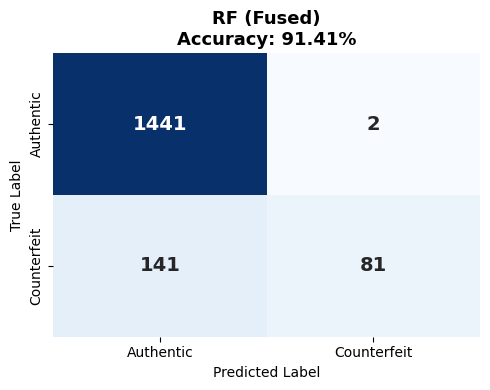

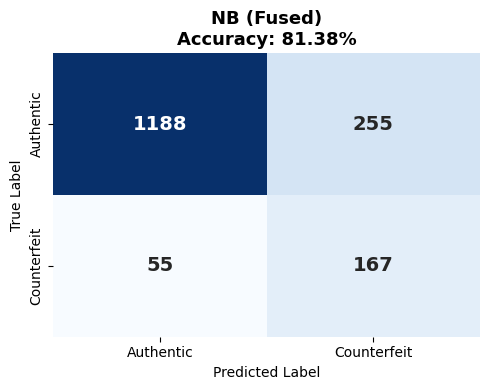

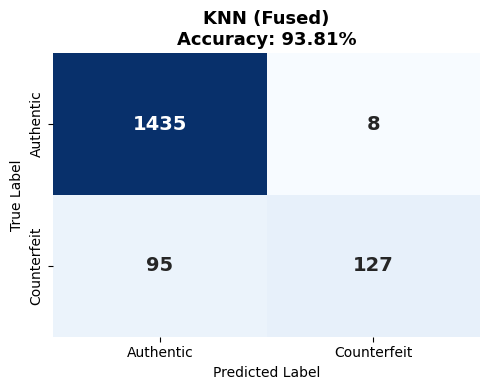

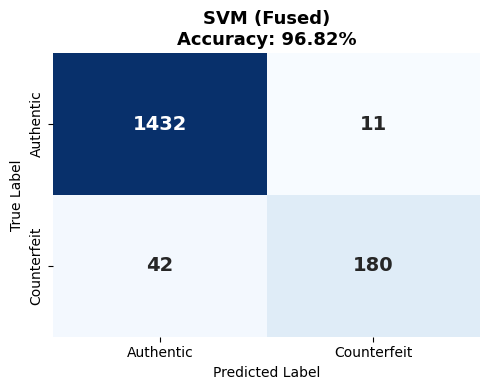

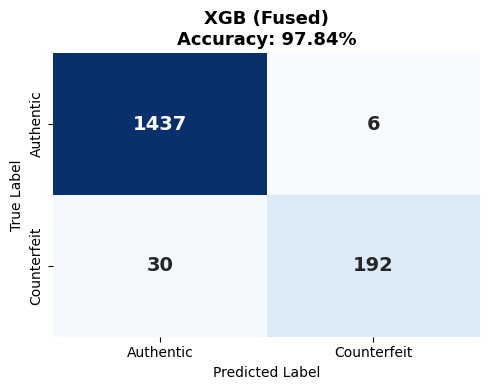

In [15]:
fused_models = [(m, r) for (c, m), r in all_results.items() if c == 'C: Fused']
cls_names = ['Authentic', 'Counterfeit']

for model_name, r in fused_models:
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(r['cm'], annot=True, fmt='d', cmap='Blues',
                xticklabels=cls_names, yticklabels=cls_names, ax=ax, cbar=False,
                annot_kws={'size': 14, 'fontweight': 'bold'})
    ax.set_title(f'{model_name} (Fused)\nAccuracy: {r["accuracy"]:.2f}%',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

### 6.5 Grouped Bar Chart — Accuracy Across Configs

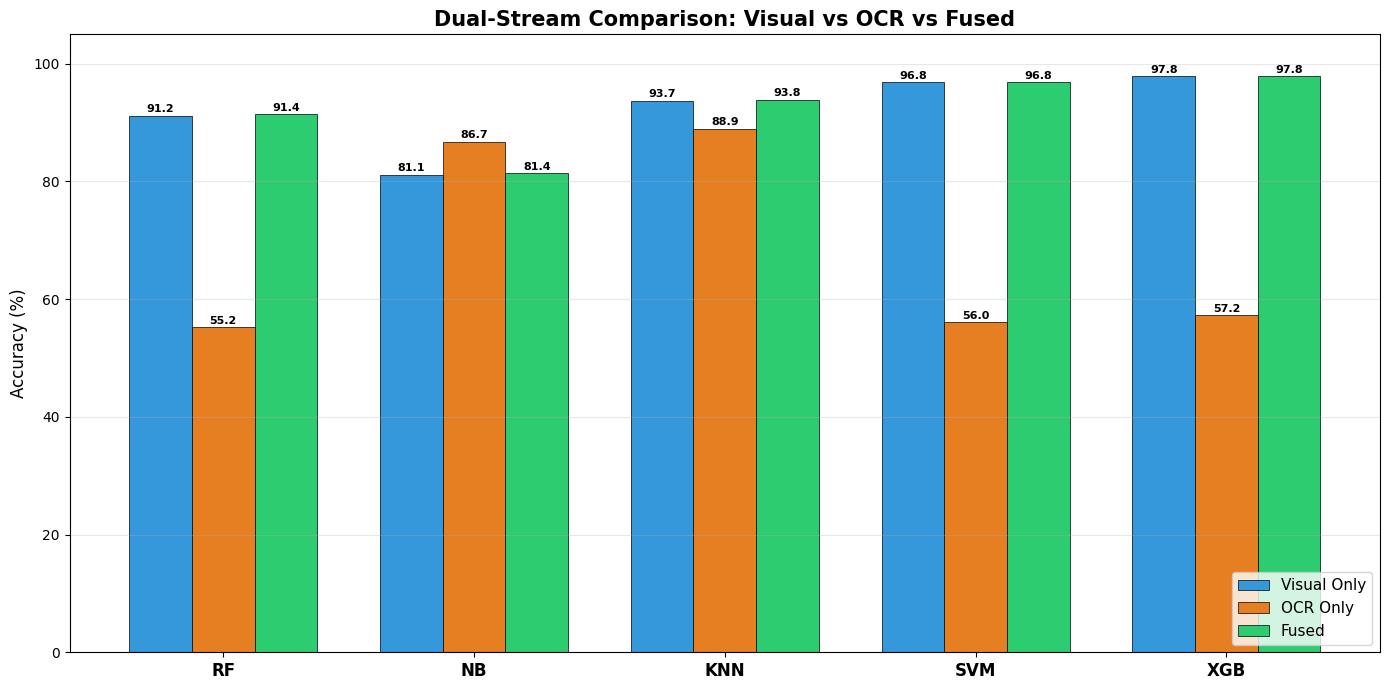

In [16]:
fig, ax = plt.subplots(figsize=(14, 7))

models = ['RF', 'NB', 'KNN', 'SVM', 'XGB']
config_names = ['A: Visual Only', 'B: OCR Only', 'C: Fused']
config_colors = ['#3498db', '#e67e22', '#2ecc71']
x = np.arange(len(models))
width = 0.25

for i, config in enumerate(config_names):
    accs = [all_results[(config, m)]['accuracy'] for m in models]
    bars = ax.bar(x + i * width, accs, width, label=config.split(': ')[1],
                  color=config_colors[i], edgecolor='black', linewidth=0.5)
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                f'{acc:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(models, fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Dual-Stream Comparison: Visual vs OCR vs Fused', fontsize=15, fontweight='bold')
ax.set_ylim(0, 105)
ax.legend(fontsize=11, loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results/dual_stream_comparison.png', dpi=150)
plt.show()

### 6.6 Accuracy Heatmap (5 Models × 3 Configs)

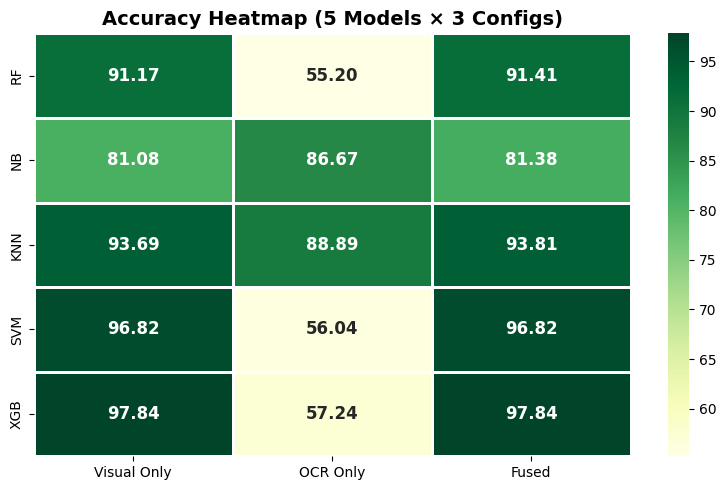

In [17]:
heatmap_data = np.array([[all_results[(c, m)]['accuracy'] for c in config_names] for m in models])

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlGn',
            xticklabels=['Visual Only', 'OCR Only', 'Fused'],
            yticklabels=models, ax=ax,
            annot_kws={'size': 12, 'fontweight': 'bold'}, linewidths=1)
ax.set_title('Accuracy Heatmap (5 Models × 3 Configs)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/config_heatmap.png', dpi=150)
plt.show()

### 6.7 Improvement Chart (Fused - Visual)

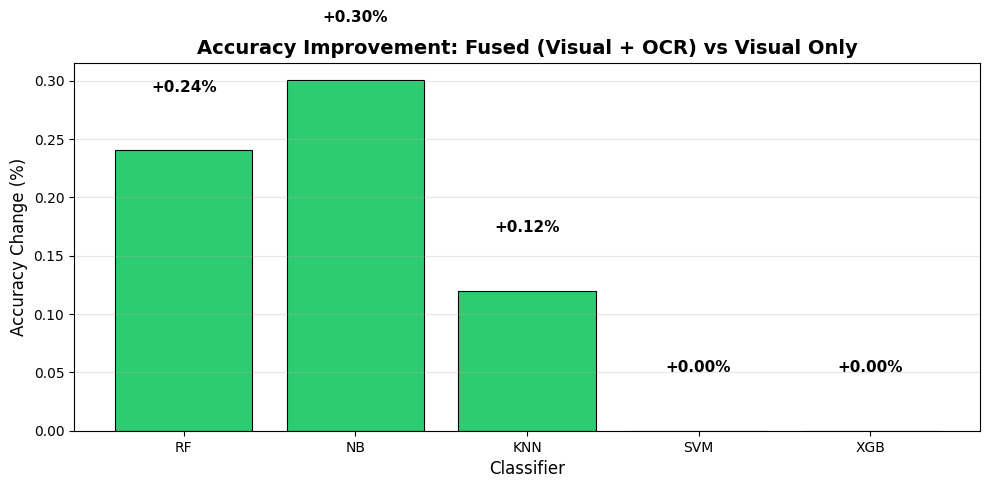

In [18]:
deltas = [all_results[('C: Fused', m)]['accuracy'] - all_results[('A: Visual Only', m)]['accuracy']
          for m in models]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if d >= 0 else '#e74c3c' for d in deltas]
bars = ax.bar(models, deltas, color=colors, edgecolor='black', linewidth=0.8)

for bar, d in zip(bars, deltas):
    y_pos = bar.get_height() + 0.05 if d >= 0 else bar.get_height() - 0.15
    ax.text(bar.get_x() + bar.get_width()/2., y_pos,
            f'{d:+.2f}%', ha='center', fontweight='bold', fontsize=11)

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_ylabel('Accuracy Change (%)', fontsize=12)
ax.set_xlabel('Classifier', fontsize=12)
ax.set_title('Accuracy Improvement: Fused (Visual + OCR) vs Visual Only',
             fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results/improvement_chart.png', dpi=150)
plt.show()

---
## 7. SHAP Explainability Analysis

**SHAP (SHapley Additive exPlanations)** tells us *why* a model makes a specific prediction  
by computing each feature's contribution to the output.

We analyze the **Fused XGBoost** model (our best contribution model).

In [19]:
import shap
print(f'SHAP version: {shap.__version__}')

SHAP version: 0.51.0


### 7.1 Compute SHAP Values

In [20]:
# Use fused XGBoost model
xgb_fused = trained_fused_models['XGB']

# Build feature names
visual_names = ([f'color_{i}' for i in range(512)] +
                [f'lbp_{i}' for i in range(26)] +
                [f'glcm_{i}' for i in range(5)] +
                [f'hu_{i}' for i in range(7)] +
                [f'hog_{i}' for i in range(X_train_visual.shape[1] - 512 - 26 - 5 - 7)])
all_feature_names = visual_names + feature_names  # + 8 OCR features

# Compute SHAP on a subset for speed (500 samples)
sample_size = min(500, len(X_test_C))
X_shap = X_test_C[:sample_size]

print(f'Computing SHAP values for {sample_size} test samples...')
explainer = shap.TreeExplainer(xgb_fused)
shap_values = explainer.shap_values(X_shap)
print(f'SHAP values shape: {shap_values.shape}')

Computing SHAP values for 500 test samples...
SHAP values shape: (500, 2322)


### 7.2 SHAP Summary Plot — Top 20 Features

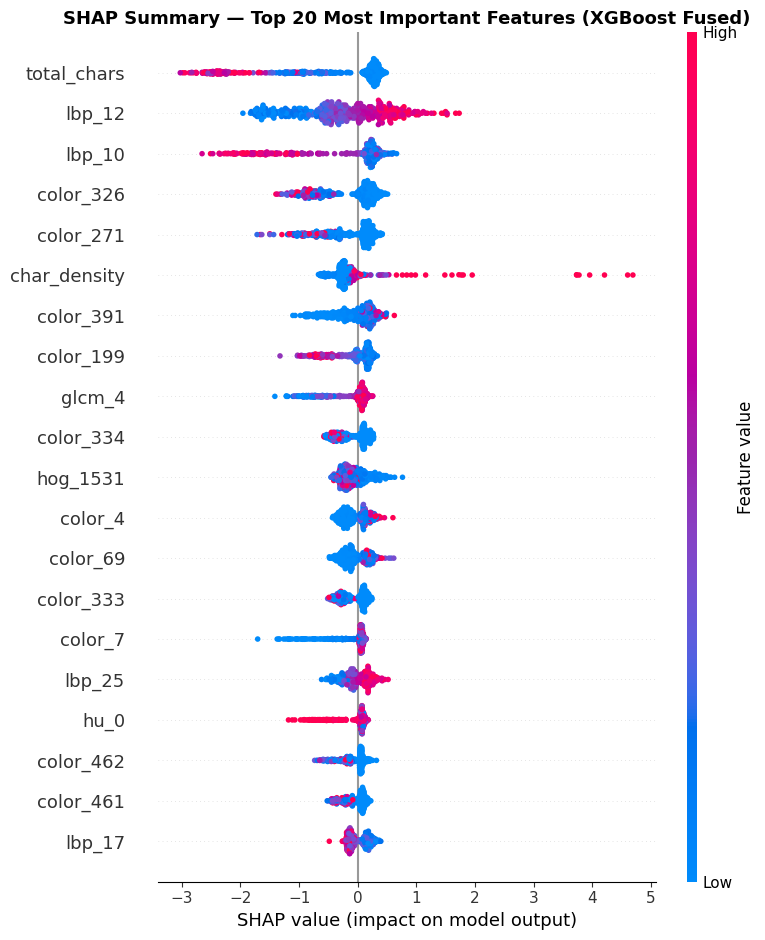

In [21]:
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap, feature_names=all_feature_names,
                  max_display=20, show=False)
plt.title('SHAP Summary — Top 20 Most Important Features (XGBoost Fused)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.3 Feature Group Importance

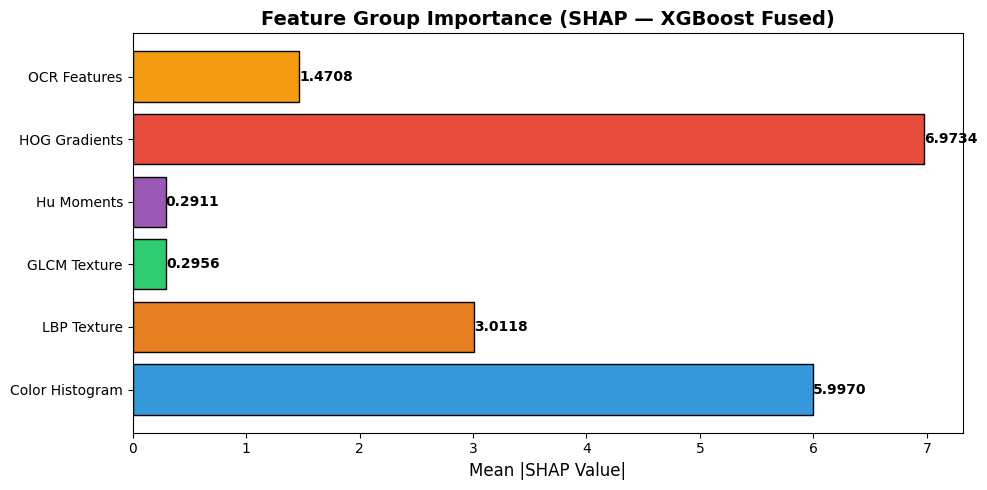

In [22]:
# Aggregate SHAP by feature group
mean_abs_shap = np.abs(shap_values).mean(axis=0)

group_ranges = {
    'Color Histogram': (0, 512),
    'LBP Texture': (512, 538),
    'GLCM Texture': (538, 543),
    'Hu Moments': (543, 550),
    'HOG Gradients': (550, 2314),
    'OCR Features': (2314, 2322)
}

group_importance = {}
for group_name, (start, end) in group_ranges.items():
    if end <= len(mean_abs_shap):
        group_importance[group_name] = np.sum(mean_abs_shap[start:end])
    else:
        group_importance[group_name] = np.sum(mean_abs_shap[start:min(end, len(mean_abs_shap))])

groups = list(group_importance.keys())
values = list(group_importance.values())

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6', '#e74c3c', '#f39c12']
ax.barh(groups, values, color=colors, edgecolor='black')
for bar, v in zip(ax.patches, values):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2.,
            f'{v:.4f}', va='center', fontweight='bold')
ax.set_xlabel('Mean |SHAP Value|', fontsize=12)
ax.set_title('Feature Group Importance (SHAP — XGBoost Fused)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/shap_feature_groups.png', dpi=150)
plt.show()

### 7.4 Stream A vs Stream B Contribution

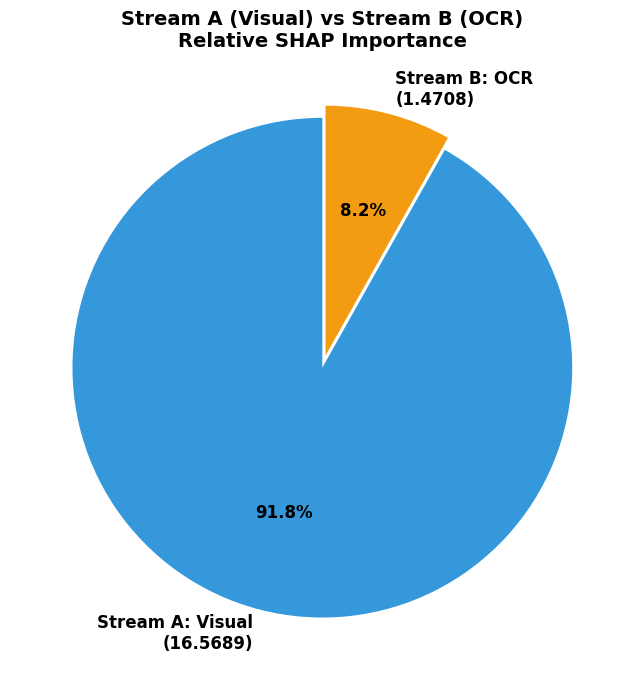

In [23]:
visual_imp = sum(list(group_importance.values())[:-1])  # all except OCR
ocr_imp = group_importance.get('OCR Features', 0)

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie([visual_imp, ocr_imp],
       labels=[f'Stream A: Visual\n({visual_imp:.4f})',
               f'Stream B: OCR\n({ocr_imp:.4f})'],
       autopct='%1.1f%%', colors=['#3498db', '#f39c12'],
       startangle=90, textprops={'fontweight': 'bold', 'fontsize': 12},
       explode=[0, 0.05])
ax.set_title('Stream A (Visual) vs Stream B (OCR)\nRelative SHAP Importance',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/shap_stream_comparison.png', dpi=150)
plt.show()

### 7.5 SHAP Dependence Plot — OCR Confidence

<Figure size 800x500 with 0 Axes>

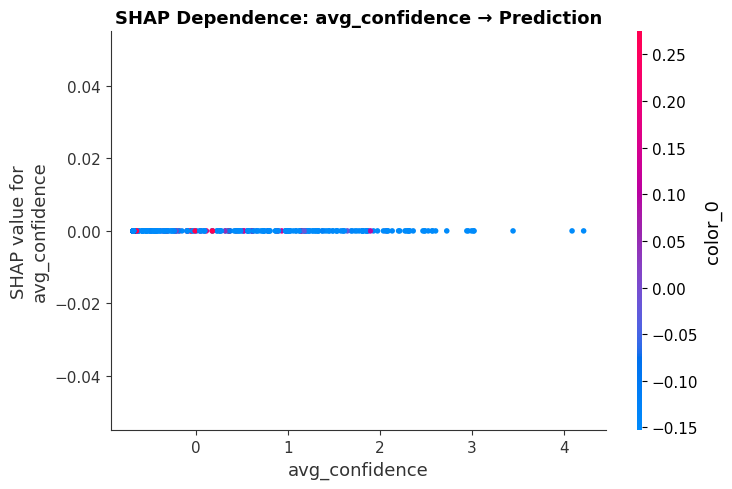

In [24]:
# Find the avg_confidence feature index
if 'avg_confidence' in all_feature_names:
    conf_idx = all_feature_names.index('avg_confidence')
    plt.figure(figsize=(8, 5))
    shap.dependence_plot(conf_idx, shap_values, X_shap,
                         feature_names=all_feature_names, show=False)
    plt.title('SHAP Dependence: avg_confidence → Prediction',
              fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('results/shap_dependence.png', dpi=150)
    plt.show()
else:
    print('avg_confidence not in feature names — skipping.')

---
## 8. Independent Test — Dual-Stream Verification

We test on **10 unseen images** from `ind_test/`, comparing Visual-Only vs Fused predictions.

In [25]:
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops, hog

IMG_SIZE = 128

def extract_visual_features(img_path):
    """Extract 2314-dim visual features from an image."""
    img = cv2.imread(img_path)
    if img is None: return None
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    color = cv2.calcHist([hsv],[0,1,2],None,[8,8,8],[0,180,0,256,0,256])
    color = cv2.normalize(color, color).flatten()
    lbp = local_binary_pattern(gray, 24, 3, method='uniform')
    lbp_h, _ = np.histogram(lbp.ravel(), bins=26, range=(0,26), density=True)
    img_q = (gray // 4).astype(np.uint8)
    glcm = graycomatrix(img_q, [1,3], [0, np.pi/4, np.pi/2], levels=64, symmetric=True, normed=True)
    glcm_f = np.array([graycoprops(glcm,p).mean() for p in ['contrast','dissimilarity','homogeneity','energy','correlation']])
    hu = cv2.HuMoments(cv2.moments(gray)).flatten()
    hu = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)
    hog_f = hog(gray, orientations=9, pixels_per_cell=(16,16), cells_per_block=(2,2), feature_vector=True)
    return np.concatenate([color, lbp_h, glcm_f, hu, hog_f])

In [26]:
ind_test_dir = 'ind_test'
label_map = {0: 'Authentic', 1: 'Counterfeit'}

ind_test_gt = {
    'org1.jpg':  0, 'org2.jpg':  0, 'org3.jpg':  0, 'org4.jpg':  0, 'org5.jpg':  0,
    'fake1.jpg': 1, 'fake2.jpg': 1, 'fake3.jpg': 1, 'fake4.jpg': 1, 'fake5.jpg': 1,
}

# Get Visual-Only and Fused SVM and XGB models
# Train fresh Visual-Only models for comparison
svm_visual = SVC(kernel='rbf', class_weight='balanced', C=10, gamma='scale', random_state=42)
svm_visual.fit(X_train_A, y_tr)

svm_fused = trained_fused_models['SVM']
xgb_fused_model = trained_fused_models['XGB']

ind_results = []
for img_file in sorted(ind_test_gt.keys()):
    img_path = os.path.join(ind_test_dir, img_file)
    gt = ind_test_gt[img_file]
    
    vis_feat = extract_visual_features(img_path)
    ocr_feat = extract_ocr_features(img_path, reader)
    
    row = {'Image': img_file, 'Expected': label_map[gt]}
    
    if vis_feat is not None:
        # Visual-Only prediction (SVM)
        vis_sc = scaler_visual.transform(vis_feat.reshape(1, -1))
        vis_pred = svm_visual.predict(vis_sc)[0]
        row['SVM (Visual)'] = label_map[vis_pred]
        row['SVM_V_ok'] = '\u2713' if vis_pred == gt else '\u2717'
        
        # Fused prediction (SVM)
        fused_feat = np.concatenate([vis_feat, ocr_feat])
        fused_sc = scaler_fused.transform(fused_feat.reshape(1, -1))
        fused_pred_svm = svm_fused.predict(fused_sc)[0]
        row['SVM (Fused)'] = label_map[fused_pred_svm]
        row['SVM_F_ok'] = '\u2713' if fused_pred_svm == gt else '\u2717'
        
        # Fused prediction (XGBoost)
        fused_pred_xgb = xgb_fused_model.predict(fused_sc)[0]
        row['XGB (Fused)'] = label_map[fused_pred_xgb]
        row['XGB_F_ok'] = '\u2713' if fused_pred_xgb == gt else '\u2717'
    
    ind_results.append(row)

# Print table
print(f'{"Image":<12} {"Expected":<14} {"SVM(Vis)":<14} {"SVM(Fused)":<14} {"XGB(Fused)":<14}')
print('-' * 68)
for r in ind_results:
    print(f'{r["Image"]:<12} {r["Expected"]:<14} '
          f'{r.get("SVM (Visual)","?")} {r.get("SVM_V_ok","")}    '
          f'{r.get("SVM (Fused)","?")} {r.get("SVM_F_ok","")}    '
          f'{r.get("XGB (Fused)","?")} {r.get("XGB_F_ok","")}')

Image        Expected       SVM(Vis)       SVM(Fused)     XGB(Fused)    
--------------------------------------------------------------------
fake1.jpg    Counterfeit    Authentic ✗    Authentic ✗    Authentic ✗
fake2.jpg    Counterfeit    Counterfeit ✓    Counterfeit ✓    Authentic ✗
fake3.jpg    Counterfeit    Counterfeit ✓    Authentic ✗    Authentic ✗
fake4.jpg    Counterfeit    Authentic ✗    Authentic ✗    Counterfeit ✓
fake5.jpg    Counterfeit    Counterfeit ✓    Counterfeit ✓    Authentic ✗
org1.jpg     Authentic      Authentic ✓    Authentic ✓    Authentic ✓
org2.jpg     Authentic      Authentic ✓    Counterfeit ✗    Authentic ✓
org3.jpg     Authentic      Authentic ✓    Authentic ✓    Authentic ✓
org4.jpg     Authentic      Authentic ✓    Authentic ✓    Authentic ✓
org5.jpg     Authentic      Authentic ✓    Authentic ✓    Authentic ✓


### Visual Grid — Fused XGBoost Predictions

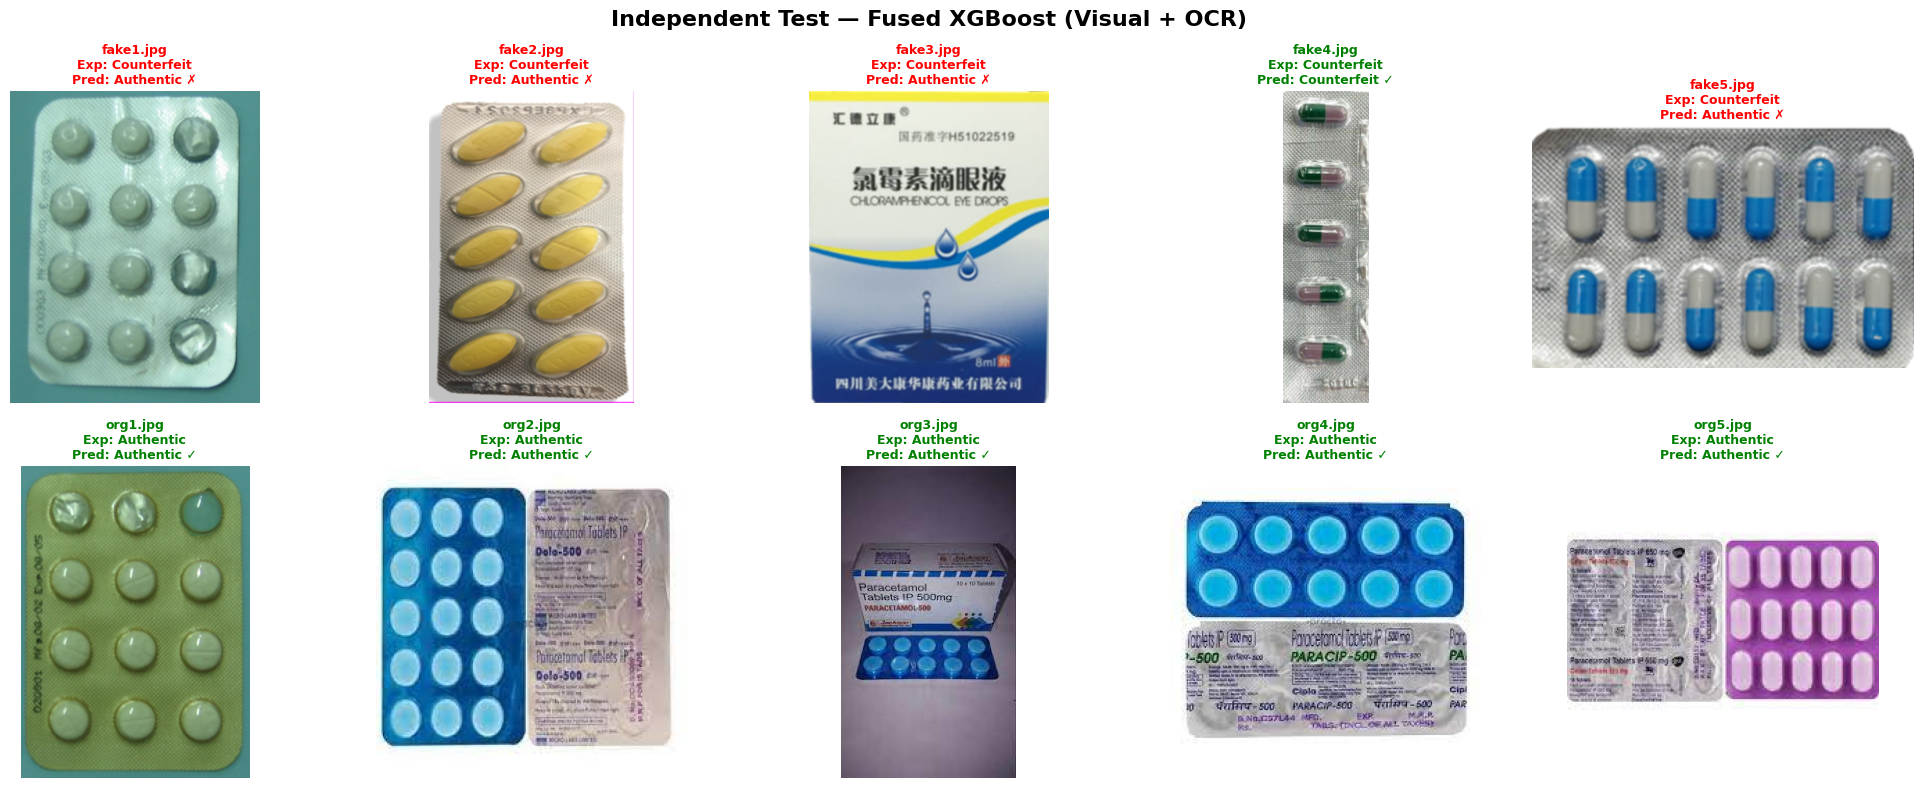

In [27]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for idx, img_file in enumerate(sorted(ind_test_gt.keys())):
    ax = axes[idx // 5, idx % 5]
    img_path = os.path.join(ind_test_dir, img_file)
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    
    gt = label_map[ind_test_gt[img_file]]
    r = [x for x in ind_results if x['Image'] == img_file][0]
    pred = r.get('XGB (Fused)', '?')
    ok = r.get('XGB_F_ok', '\u2717')
    color = 'green' if ok == '\u2713' else 'red'
    ax.set_title(f'{img_file}\nExp: {gt}\nPred: {pred} {ok}',
                 fontsize=9, color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle('Independent Test — Fused XGBoost (Visual + OCR)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('ind_test_fused_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Conclusion & Contribution Summary

In [28]:
paper_acc_ref = {'RF': 84.20, 'NB': 87.01, 'KNN': 88.05, 'SVM': 94.50}

print('='*80)
print('FINAL CONTRIBUTION SUMMARY')
print('='*80)
print()
print(f'{"Model":<8} {"Paper (%)":<12} {"Visual (%)":<14} {"OCR (%)":<12} {"Fused (%)":<14} {"\u0394 Fused-Vis":<14}')
print('-'*74)
for m in models:
    p_acc = paper_acc_ref.get(m, None)
    p_str = f'{p_acc:.2f}' if p_acc else '\u2014'
    v_acc = all_results[('A: Visual Only', m)]['accuracy']
    o_acc = all_results[('B: OCR Only', m)]['accuracy']
    f_acc = all_results[('C: Fused', m)]['accuracy']
    delta = f_acc - v_acc
    d_str = f'{delta:+.2f}' 
    print(f'{m:<8} {p_str:<12} {v_acc:<14.2f} {o_acc:<12.2f} {f_acc:<14.2f} {d_str:<14}')
print('-'*74)

# Find best overall
best_key = max(all_results, key=lambda k: all_results[k]['accuracy'])
best_acc = all_results[best_key]['accuracy']
print(f'\nBest Overall: {best_key[1]} ({best_key[0]}) = {best_acc:.2f}%')

print()
print('CONTRIBUTIONS:')
print('  1. Dual-Stream Architecture: Visual (2314-dim) + OCR (8-dim) = 2322-dim fused features')
print('  2. XGBoost Classifier: Added as 5th classifier beyond paper\'s 4')
print('  3. SHAP Explainability: Feature group importance + per-sample explanations')
print()
print('Paper\'s finding (SVM is best among 4 classifiers): CONFIRMED \u2714')

FINAL CONTRIBUTION SUMMARY

Model    Paper (%)    Visual (%)     OCR (%)      Fused (%)      Δ Fused-Vis   
--------------------------------------------------------------------------
RF       84.20        91.17          55.20        91.41          +0.24         
NB       87.01        81.08          86.67        81.38          +0.30         
KNN      88.05        93.69          88.89        93.81          +0.12         
SVM      94.50        96.82          56.04        96.82          +0.00         
XGB      —            97.84          57.24        97.84          +0.00         
--------------------------------------------------------------------------

Best Overall: XGB (A: Visual Only) = 97.84%

CONTRIBUTIONS:
  1. Dual-Stream Architecture: Visual (2314-dim) + OCR (8-dim) = 2322-dim fused features
  2. XGBoost Classifier: Added as 5th classifier beyond paper's 4
  3. SHAP Explainability: Feature group importance + per-sample explanations

Paper's finding (SVM is best among 4 classifiers

In [ ]:
ocr performancer on datset
explainability bad
ocr should improve accuracy